# Two Types - NonCongruent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tfds.plotting import prettify, use_tex
from scipy.optimize import minimize
#use_tex()

In [2]:
def objective(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - pi2_h) - (1 - 2 * prob_state0) * (1 - pi2_h))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (pi1_l - 1))
    return -gamma * (trans_h - cost_h) - (1-gamma) * (trans_l - cost_l)

def ic_l(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    return theta_l * (pi1_l + pi2_h - 2) + 1 - pi2_h - trans_l + trans_h


def ic_h(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    return theta_h * (2 - pi1_l - pi2_h) - 1 + pi2_h - trans_h + trans_l


def ir_l(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    return theta_l * pi1_l - trans_l

def ir_h(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    return (1 - theta_h) * pi2_h - trans_h

bounds = [(0, 1), (0, 1), (0, None), (0, None)]

# Initial guess for the variables
tau = 0.28
prob_state0 = 0.9
theta_h = 0.7
theta_l = 0.2
gamma = 0.5


constraints = [
        {'type': 'ineq', 'fun': ic_l},
        {'type': 'ineq', 'fun': ic_h},
        {'type': 'eq', 'fun': ir_l},
        {'type': 'eq', 'fun': ir_h},
    ]
x0 = [1, 1, 1, 1]
result = minimize(
            objective,
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            tol=1e-10,
            options={"maxiter":10000000}
        )

    
result.x
pi1_l, pi2_h, trans_l, trans_h = result.x
np.round(result.x, 3)

array([0. , 1. , 0. , 0.3])

Text(0, 0.5, 'Threshold $\\tau$')

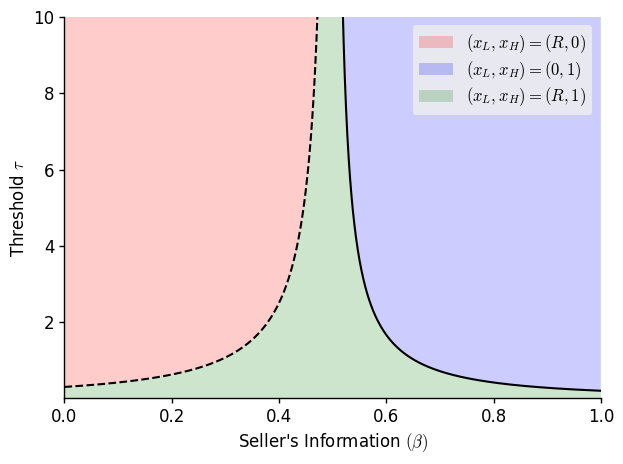

In [75]:
def D(prob_state0):
    return (1 - 2 * prob_state0) * (1 - prob_state0)

def tau_critical_l(theta_l, prob_state0):
    return theta_l / (prob_state0 * (2 * prob_state0 - 1))

def tau_critical_h(theta_h, prob_state0):
    return (1 - theta_h) / D(prob_state0)
    
gamma = 0.5
tau = 1
theta_h = 0.7
theta_l = 0.2
tau = 1
N = 10000

prob_state0s = np.linspace(0, 1, N)

fig, ax = plt.subplots()
# ax.plot(prob_state0s, tau_critical_l(theta_l, prob_state0s))

with np.errstate(divide='ignore'):
    tau_critical_hs = tau_critical_h(theta_h, prob_state0s)
tau_critical_hs[tau_critical_hs <= 0] = 1e-5

with np.errstate(divide='ignore'):
    tau_critical_ls = tau_critical_l(theta_l, prob_state0s)
tau_critical_ls[tau_critical_ls <= 0] = 1e-5

with np.errstate(divide='ignore'):
    tau_critical_hs = tau_critical_h(theta_h, prob_state0s)
tau_critical_hs[tau_critical_hs <= 0] = np.nan

with np.errstate(divide='ignore'):
    tau_critical_ls = tau_critical_l(theta_l, prob_state0s)
tau_critical_ls[tau_critical_ls <= 0] = np.nan

ax.plot(prob_state0s, tau_critical_ls, color="k", ls="solid")
ax.plot(prob_state0s, tau_critical_hs, color="k", ls="dashed")



ax.fill_between(
    prob_state0s[prob_state0s <= 0.5],
    tau_critical_hs[prob_state0s <= 0.5],
    np.nanmax(tau_critical_hs),
    facecolor="red", 
    alpha=.2,
    label=r"$(x_L, x_H) = (R, 0)$"
)
ax.fill_between(
    prob_state0s[prob_state0s >= 0.5],
    tau_critical_ls[prob_state0s >= 0.5],
    np.nanmax(tau_critical_ls),
    facecolor="blue", 
    alpha=.2,
    label=r"$(x_L, x_H) = (0, 1)$"
)

ax.fill_between(
    prob_state0s,
    0,
    np.concatenate(
        [
            tau_critical_hs[prob_state0s <= 0.5],
            tau_critical_ls[prob_state0s > 0.5]
        ]
    ),
    facecolor="green", 
    alpha=.2,
    label=r"$(x_L, x_H) = (R, 1)$"
)



prettify(ax=ax, legend=True)


# ax.set_ylim(top=100, bottom=0)
# ax.set_yscale("log")
ax.set_ylim(top=10, bottom=0.01)
ax.set_xlim(left=0, right=1)
ax.set_xlabel(r"Seller's Information $(\beta)$")
ax.set_ylabel(r"Threshold $\tau$")

In [71]:
def objective(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - pi2_h) - (1 - 2 * prob_state0) * (1 - pi2_h))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (pi1_l - 1))
    return -gamma * (trans_h - cost_h) - (1-gamma) * (trans_l - cost_l)

def ic_l(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    return theta_l * (pi1_l + pi2_h - 2) + 1 - pi2_h - trans_l + trans_h


def ic_h(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    return theta_h * (2 - pi1_l - pi2_h) - 1 + pi2_h - trans_h + trans_l


def ir_l(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    return theta_l * pi1_l - trans_l

def ir_h(vars):
    pi1_l, pi2_h, trans_l, trans_h = vars
    return (1 - theta_h) * pi2_h - trans_h

bounds = [(0, 1), (0, 1), (0, None), (0, None)]

# Initial guess for the variables
tau = 3
prob_state0 = 0.6
theta_h = 0.7
theta_l = 0.2
gamma = 0.5


constraints = [
        {'type': 'ineq', 'fun': ic_l},
        {'type': 'ineq', 'fun': ic_h},
        {'type': 'eq', 'fun': ir_l},
        {'type': 'eq', 'fun': ir_h},
    ]
x0 = [1, 1, 1, 1]
result = minimize(
            objective,
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            tol=1e-10,
            options={"maxiter":10000000}
        )

    
result.x
pi1_l, pi2_h, trans_l, trans_h = result.x
np.round(result.x, 3)

array([0. , 1. , 0. , 0.3])